#### Medallion Architecture

1. Create the bronze_WorldHappiness dataframe to load the raw data
2. Create the silver_WorldHappiness dataframe to do all the transformations
3. Create the gold_Worldhappiness dataframe with data to be consumed by the stakeholder


In [2]:
#Create a bronze_WorldHappiness dataframe

bronze_WorldHappiness = spark.read.table("WorldHappiness")

StatementMeta(, 2af9ce69-61a6-4243-ba61-e35d4e576131, 4, Finished, Available, Finished, False)

In [18]:
#Create bronze_Worldhappiness returning only distinct values as well as a CountryKey column
from pyspark.sql.window import Window
from pyspark.sql.functions import row_number, current_timestamp, col


bronze_country = (
    bronze_WorldHappiness
        .select("Country")              
        .distinct()                      
        .orderBy("Country")             
        .withColumn(                    
            "CountryKey",
            row_number().over(Window.orderBy(col("Country")))
        )
        .withColumn("ETLLoadDate", current_timestamp())  
        .select("CountryKey", "Country", "ETLLoadDate") 
)

StatementMeta(, de8c6ca2-cfcb-4264-b476-a07469a9e985, 20, Finished, Available, Finished, False)

In [19]:
#Remove incorrect naming of countries
from pyspark.sql.functions import col

silver_country = bronze_country.filter(
    (col("Country") != "Eswatini, Kingdom of") &
    (col("Country") != "Hong Kong S.A.R. of China") &
    (col("Country") != "Turkey") &
    (col("Country") != "Viet Nam") &
    (col("Country") != "xx") &
    (col("Country") != "Turkiye")
)

display(silver_country)

StatementMeta(, de8c6ca2-cfcb-4264-b476-a07469a9e985, 21, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 214d08da-11a8-4f06-8c59-a88ff56e7d1b)

In [21]:
#Load data into delta tables
silver_country.write.mode("overwrite").format("delta").saveAsTable("DimCountry")

StatementMeta(, de8c6ca2-cfcb-4264-b476-a07469a9e985, 23, Finished, Available, Finished, False)

In [8]:

from pyspark.sql.functions import date_format, current_timestamp, col, year, month, dayofmonth

# Create a date dataframe
silver_date = (
    bronze_WorldHappiness
        .select("DatePublished")              
        .distinct()                      
        .orderBy("DatePublished")             
        .withColumn(                    
            "DateKey",
            date_format(col("DatePublished"), "yyyyMMdd").cast("int")
        )
        .withColumn("Year", year(col("DatePublished")))
        .withColumn("Month", date_format(col("DatePublished"),"MMMM").cast("string"))
        .withColumn("Day", dayofmonth(col("DatePublished")))
        .withColumn("ETLLoadDate", current_timestamp())  
    .select("DateKey", "DatePublished", "Year", "Month", "Day", "ETLLoadDate") 
)

display(silver_date)

StatementMeta(, 2af9ce69-61a6-4243-ba61-e35d4e576131, 10, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, c54f9ff7-b793-42a7-8746-d5082c06ce02)

In [9]:
#Load data into delta tables
silver_date.write.mode("overwrite").format("delta").saveAsTable("DimDate")

StatementMeta(, 2af9ce69-61a6-4243-ba61-e35d4e576131, 11, Finished, Available, Finished, False)

##### **Dataflow Gen2 - FactHappiness**

StatementMeta(, 1f29b17c-c029-4404-8bab-9499fd8a0fcd, 8, Finished, Available, Finished, False)

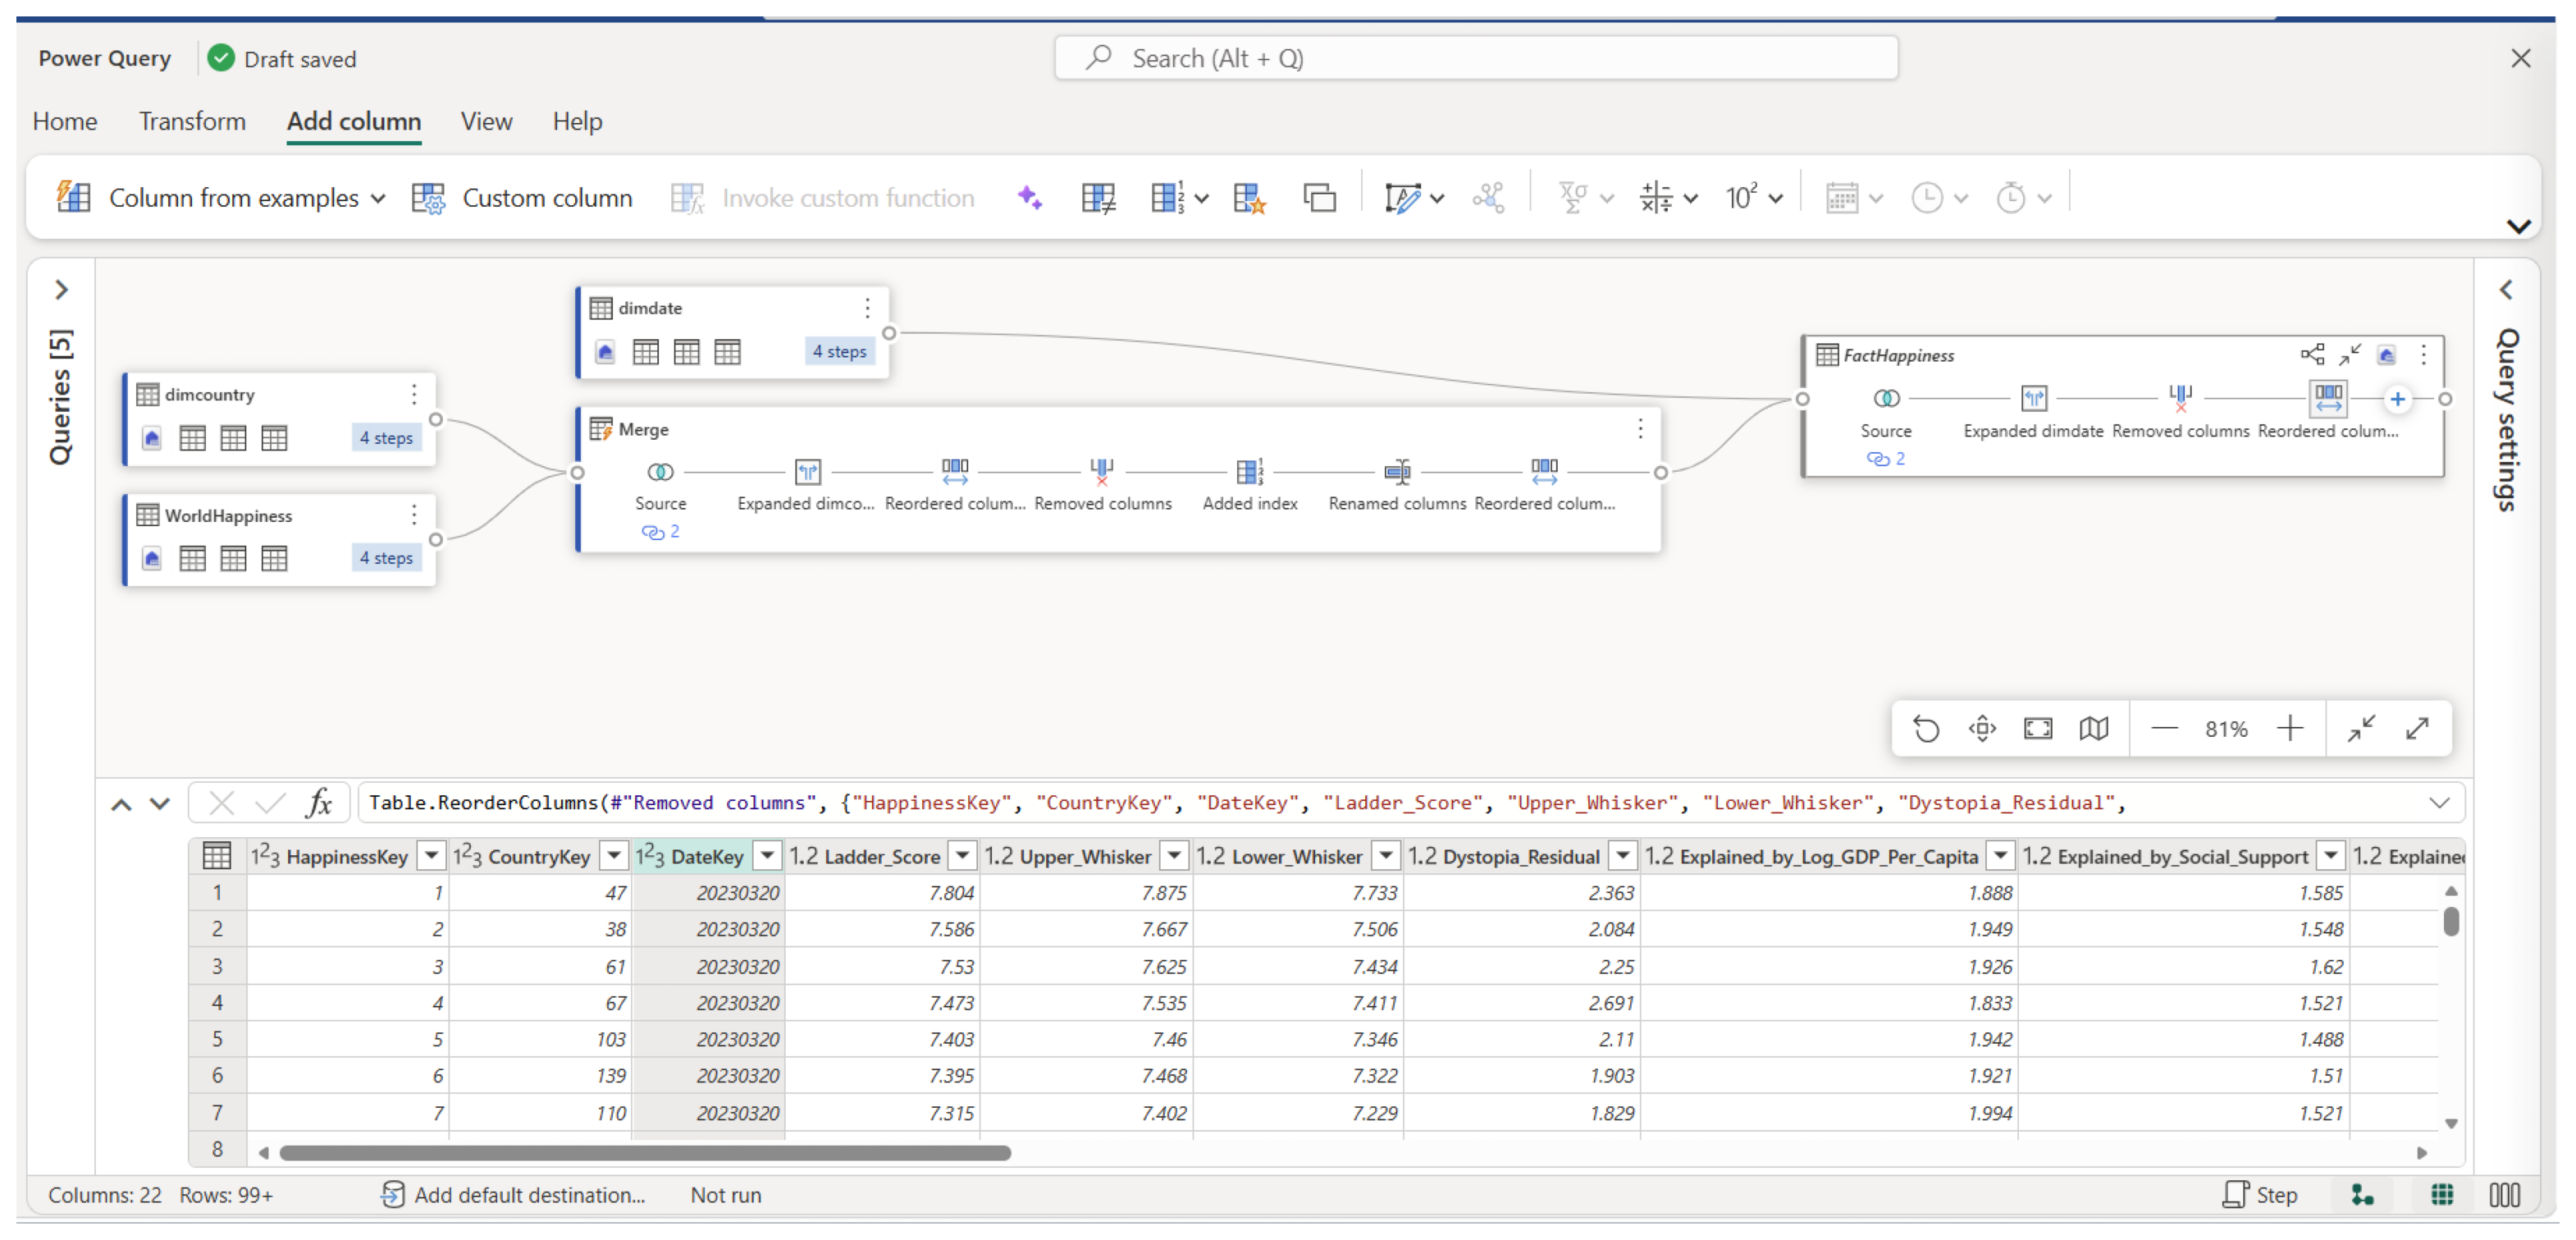

In [12]:
#Create FactHappiness table using Dataflow Gen2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/Dataflow FactHappiness.png")
plt.figure(figsize=(20, 12), dpi=200)
image_plot = plt.imshow(image)
plt.axis('off')
plt.show()


##### **Semantic Model**

StatementMeta(, 1f29b17c-c029-4404-8bab-9499fd8a0fcd, 53, Finished, Available, Finished, False)

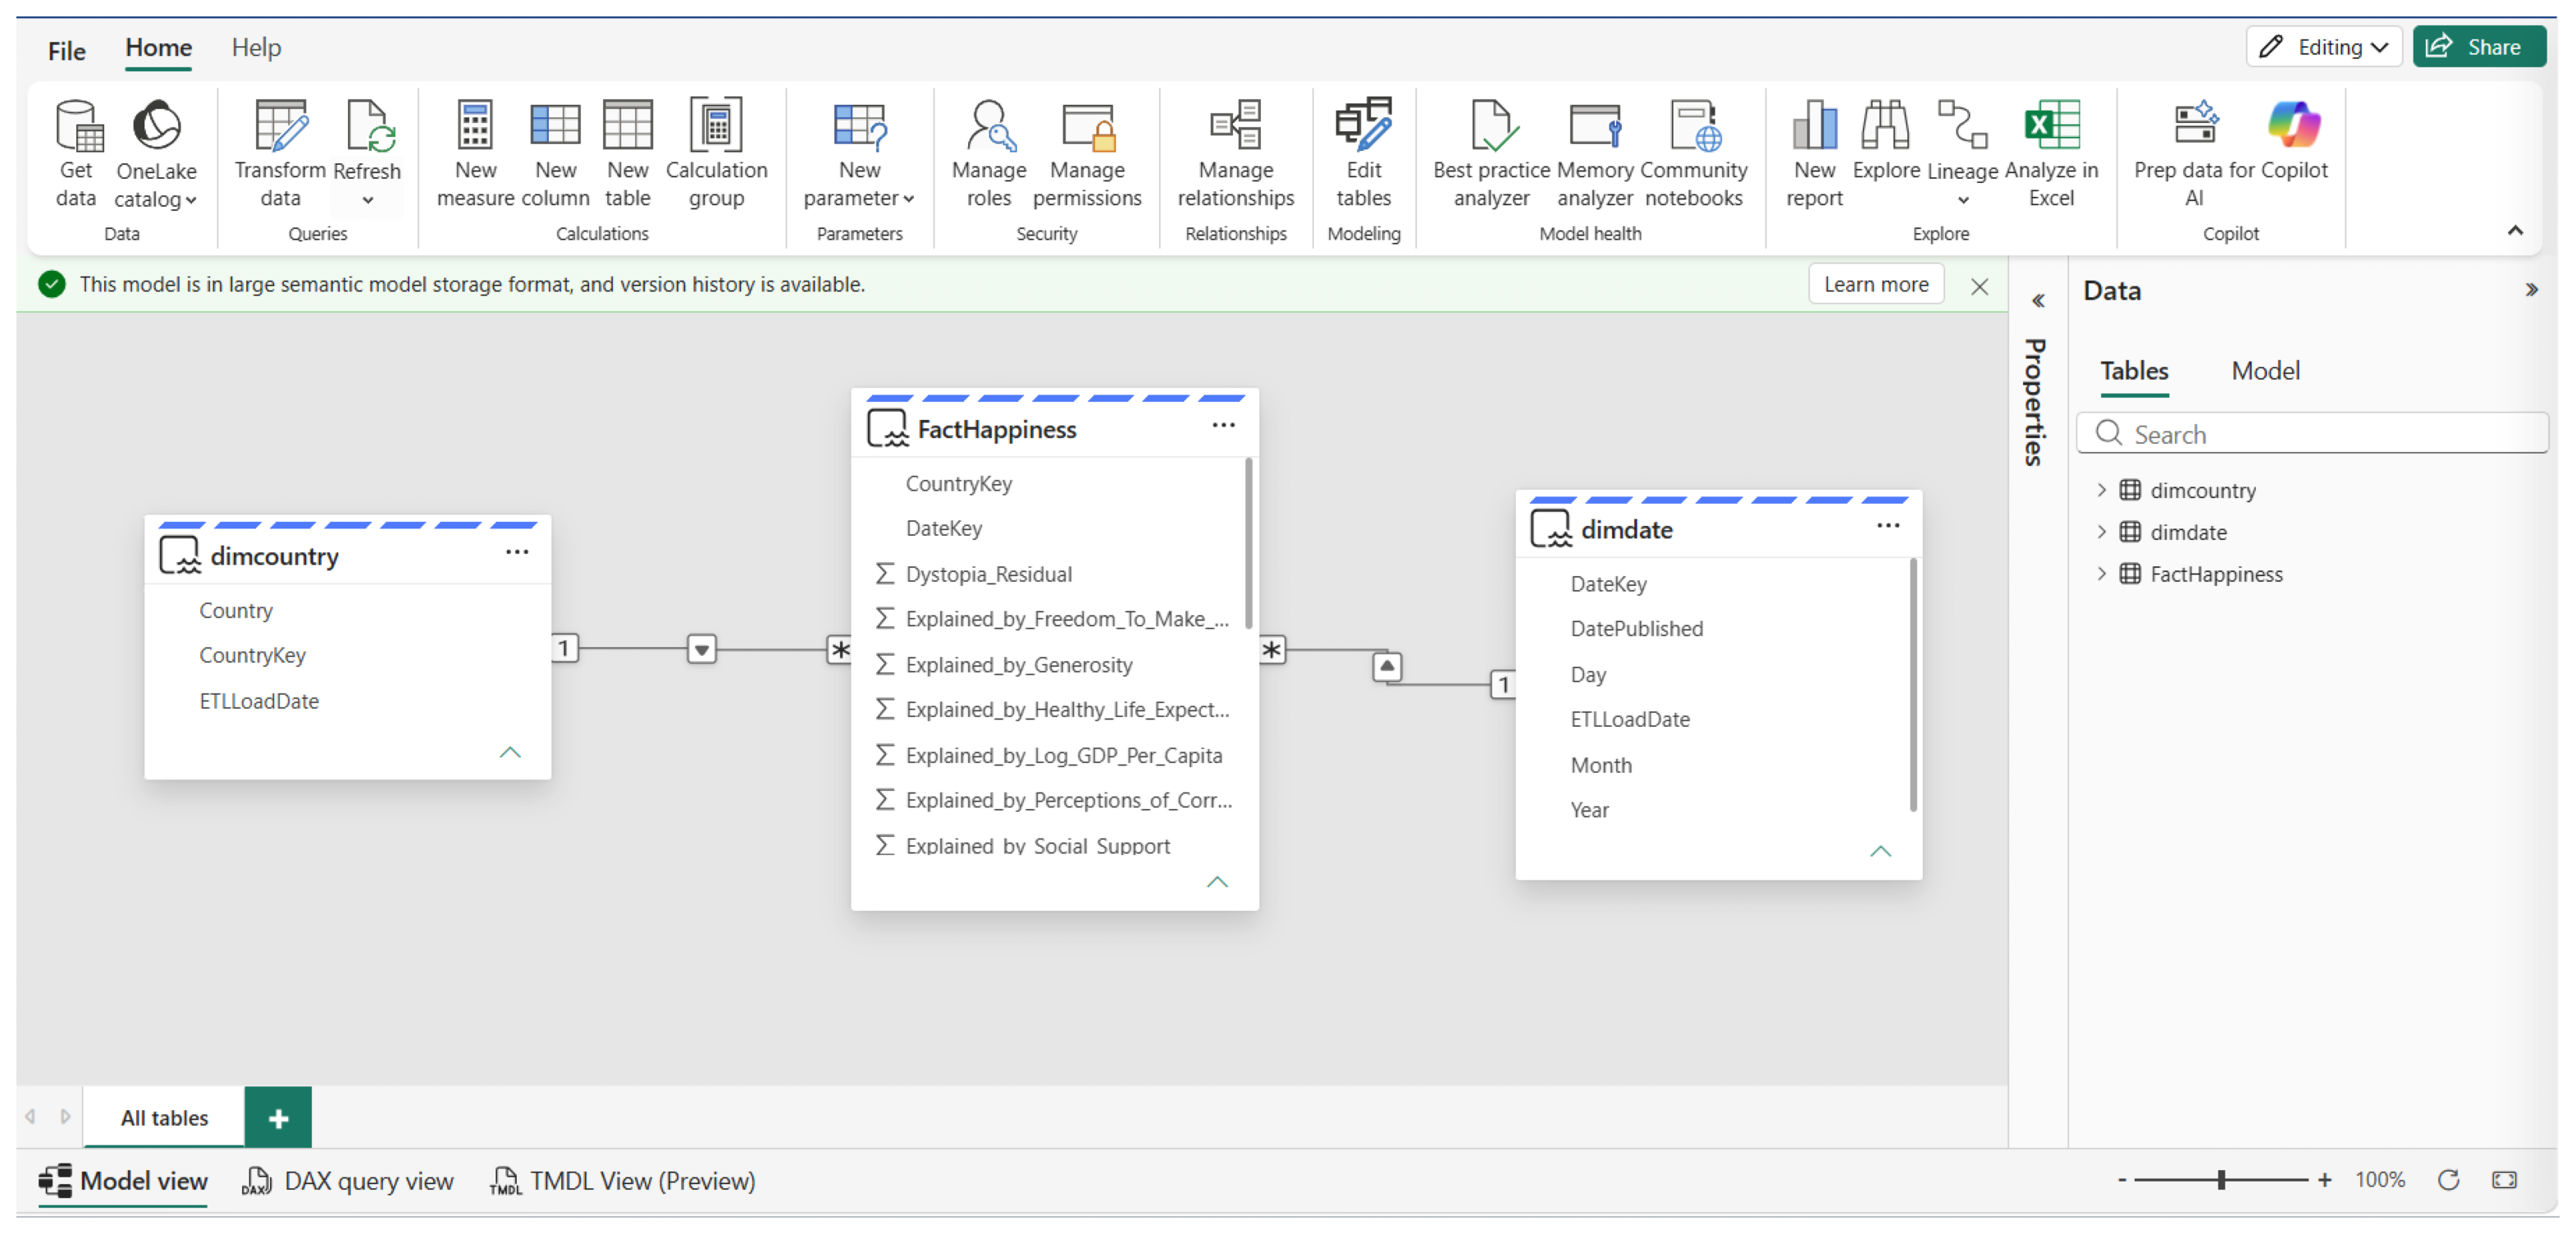

In [13]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/Semantic Model.png")
plt.figure(figsize=(20, 12), dpi=200)
image_plot = plt.imshow(image)
plt.axis('off')
plt.show()



### **Microsoft Fabric Workspace**

This shows all the objects I used in this project to achieve my goal of extracting data from the World Happiness website and loading it into Fabric and doing some transformation and eventually creating a semantic model

StatementMeta(, 3f8b6f08-ca36-4638-acbf-d6a429900275, 6, Finished, Available, Finished, False)

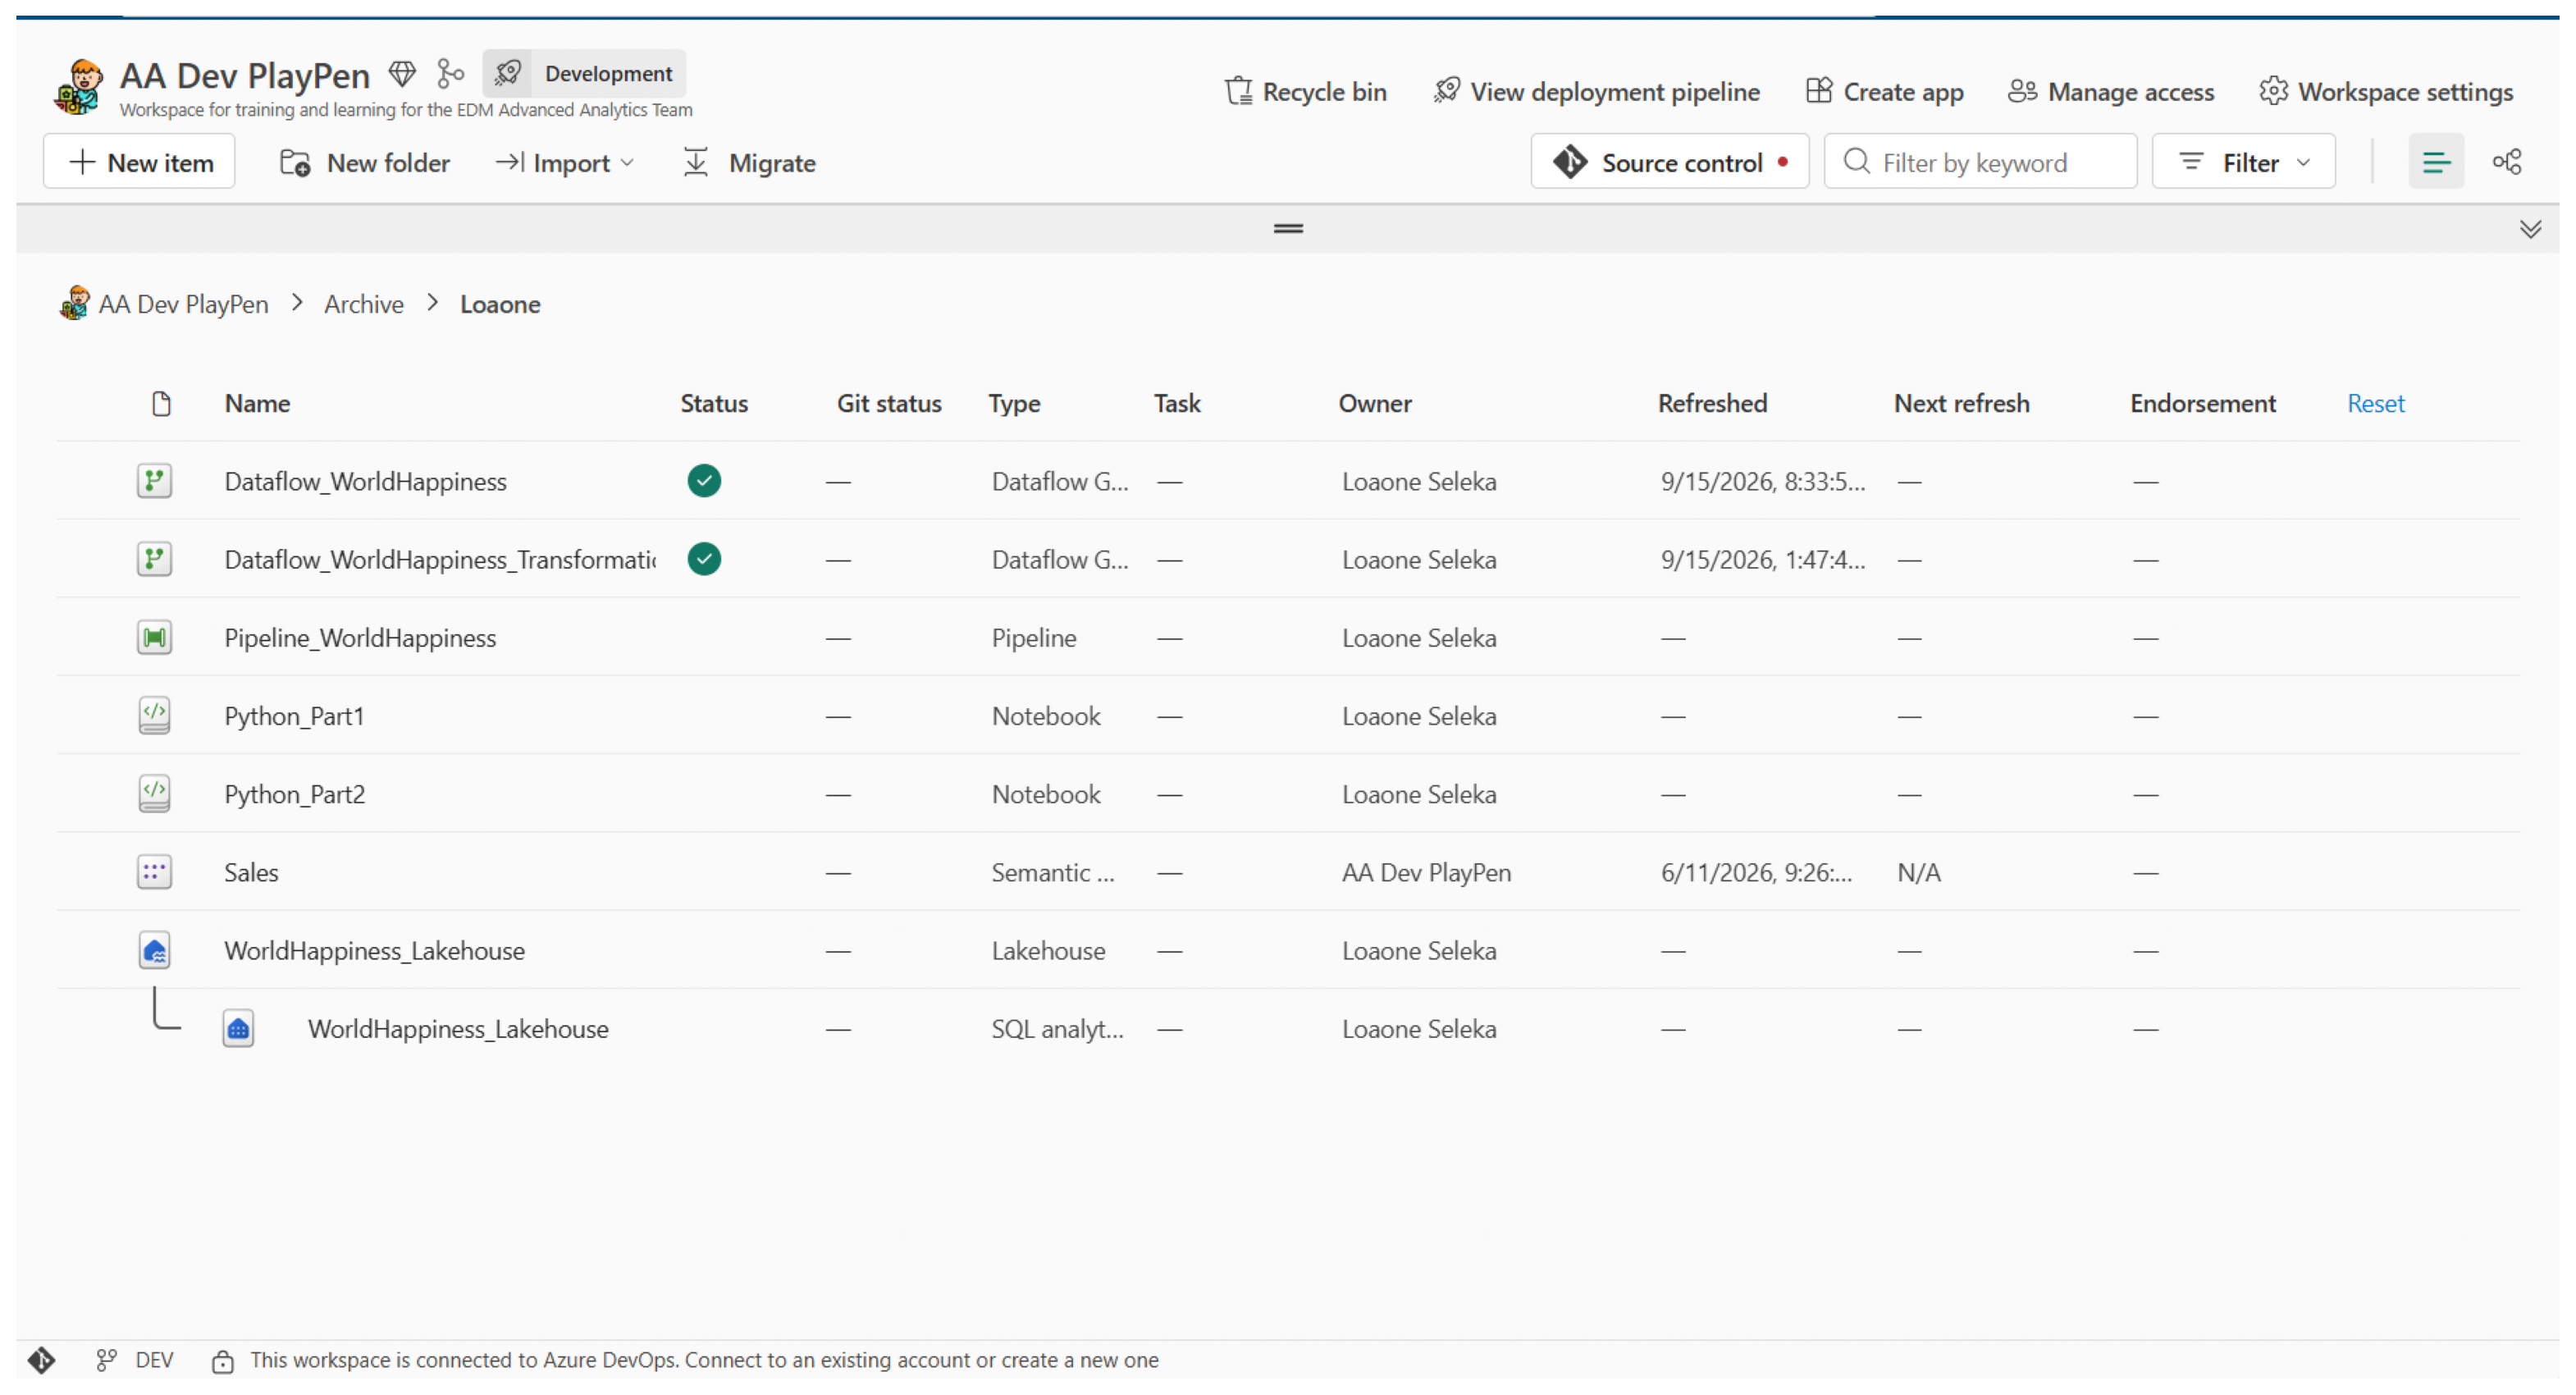

In [2]:

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Load image
image = mpimg.imread("/lakehouse/default/Files/Workspace.png")
plt.figure(figsize=(20, 12), dpi=200)
image_plot = plt.imshow(image)
plt.axis('off')
plt.show()
